In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape
from skimage.feature import hog
import tensorflow as tf
import keras
from tensorflow.keras import layers

In [ ]:
train_dir = '/content/drive/MyDrive/datasplit/Train'
val_dir = '/content/drive/MyDrive/datasplit/Test'

batch_size = 32
img_size = (64,64)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4355 images belonging to 36 classes.
Found 1801 images belonging to 36 classes.


In [ ]:

def extract_hog_features(img):
    fd, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, multichannel=True)
    return fd

def get_data_generator(generator):
    while True:
        x_batch, y_batch = generator.next()
        x_batch_hog = np.zeros((x_batch.shape[0], 1764))  # 64x64x3 -> 7x7x36
        for i in range(x_batch.shape[0]):
            x_batch_hog[i] = extract_hog_features(x_batch[i])
        yield x_batch_hog, y_batch

train_hog_generator = get_data_generator(train_generator)
val_hog_generator = get_data_generator(val_generator)


###Sample

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:

# define the CNN model architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36, activation='softmax'))


In [ ]:

# compile the model with appropriate optimizer, loss function, and metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:


history = model.fit(train_generator, epochs=15, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_generator, validation_steps=val_generator.n//batch_size)

Epoch 1/15
136/136 [==============================] - 2033s 15s/step - loss: 3.2611 - accuracy: 0.1080 - val_loss: 2.4559 - val_accuracy: 0.4174
Epoch 2/15
136/136 [==============================] - 76s 556ms/step - loss: 1.4677 - accuracy: 0.5598 - val_loss: 1.6101 - val_accuracy: 0.5882
Epoch 3/15
136/136 [==============================] - 64s 471ms/step - loss: 0.7331 - accuracy: 0.7735 - val_loss: 1.7021 - val_accuracy: 0.5804
Epoch 4/15
136/136 [==============================] - 65s 480ms/step - loss: 0.4984 - accuracy: 0.8471 - val_loss: 1.7061 - val_accuracy: 0.6094
Epoch 5/15
136/136 [==============================] - 63s 465ms/step - loss: 0.3745 - accuracy: 0.8816 - val_loss: 1.8800 - val_accuracy: 0.6267
Epoch 6/15
136/136 [==============================] - 64s 466ms/step - loss: 0.3026 - accuracy: 0.9040 - val_loss: 1.9641 - val_accuracy: 0.6060
Epoch 7/15
136/136 [==============================] - 75s 555ms/step - loss: 0.2566 - accuracy: 0.9207 - val_loss: 1.5196 - val_ac

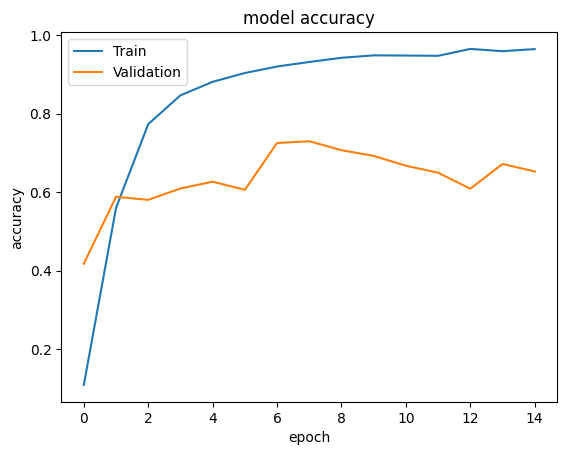

In [ ]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

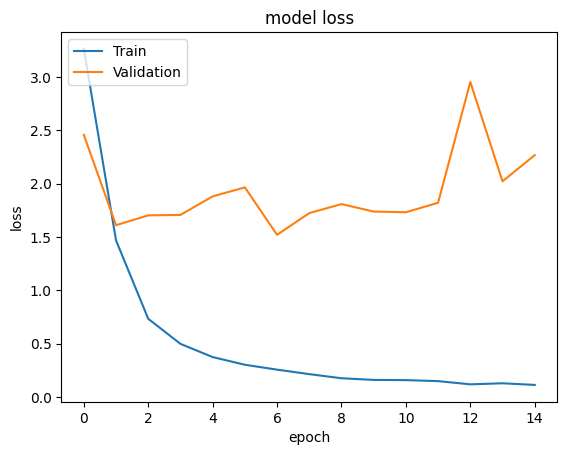

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

In [ ]:

# define callbacks to prevent overfitting
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min', min_lr=0.0001)


In [ ]:

# fit the model with the training dataset and validate it with the testing dataset
history = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[early_stop, reduce_lr])

Epoch 1/15
137/137 [==============================] - 66s 481ms/step - loss: 0.1230 - accuracy: 0.9584 - val_loss: 2.8125 - val_accuracy: 0.6557 - lr: 1.0000e-04
Epoch 2/15
137/137 [==============================] - 74s 542ms/step - loss: 0.1238 - accuracy: 0.9591 - val_loss: 2.8396 - val_accuracy: 0.6385 - lr: 1.0000e-04
Epoch 3/15
137/137 [==============================] - 75s 549ms/step - loss: 0.1313 - accuracy: 0.9538 - val_loss: 2.8692 - val_accuracy: 0.6774 - lr: 1.0000e-04
Epoch 4/15
137/137 [==============================] - 66s 481ms/step - loss: 0.1259 - accuracy: 0.9566 - val_loss: 2.8214 - val_accuracy: 0.6574 - lr: 1.0000e-04
Epoch 5/15
137/137 [==============================] - 75s 546ms/step - loss: 0.1250 - accuracy: 0.9600 - val_loss: 2.7935 - val_accuracy: 0.6619 - lr: 1.0000e-04
Epoch 6/15
137/137 [==============================] - 75s 544ms/step - loss: 0.1132 - accuracy: 0.9610 - val_loss: 2.8023 - val_accuracy: 0.6730 - lr: 1.0000e-04
Epoch 7/15
137/137 [========

KeyboardInterrupt: ignored

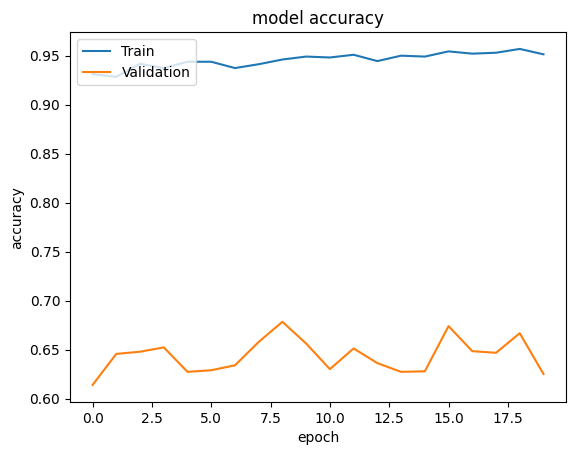

In [ ]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

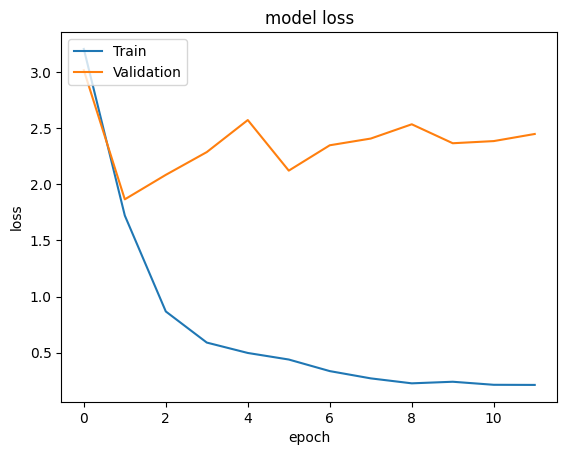

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

In [ ]:

# fit the model with the training dataset and validate it with the testing dataset
history = model.fit(train_hog_generator, epochs=10, validation_data=val_hog_generator, callbacks=[early_stop, reduce_lr])

###HyperParameter Tuning


In [ ]:
!pip install -U keras-tuner

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 6.5 MB/s eta 0:00:00


In [ ]:

import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch


<ipython-input-19-fd06f55df159>:5: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [ ]:

# define the search space
def build_model(hp):
    model = Sequential()
#    model.add(Reshape((42, 42, 1), input_shape=(1764,)))
    model.add(Conv2D(hp.Int('conv1_filters', min_value=32, max_value=32, step=32), (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
    model.add(Conv2D(hp.Int('conv2_filters', min_value=32, max_value=32, step=32), (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
#    model.add(Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.1, step=0.1)))

    model.add(Conv2D(hp.Int('conv3_filters', min_value=64, max_value=64, step=64), (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(hp.Int('conv4_filters', min_value=64, max_value=64, step=64), (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
 #   model.add(Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.1, step=0.1)))

    model.add(Flatten())
    model.add(Dense(hp.Int('dense1_units', min_value=512, max_value=512, step=512), activation='relu'))
    model.add(Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.2, step=0.1)))
    model.add(Dense(36, activation='softmax'))

    # compile the model
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  metrics=['accuracy'])
    return model


In [ ]:
# define the tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='my_project')


In [ ]:

# perform the search
tuner.search(train_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size,
             validation_data=val_generator, validation_steps=val_generator.n//batch_size)



Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
32                |32                |conv1_filters
32                |32                |conv2_filters
64                |64                |conv3_filters
64                |64                |conv4_filters
512               |512               |dense1_units
0.2               |0.2               |dropout3
0.01              |0.01              |learning_rate

Epoch 1/5
136/136 [==============================] - 158s 1s/step - loss: 4.8762 - accuracy: 0.0243 - val_loss: 3.5842 - val_accuracy: 0.0279
Epoch 2/5
136/136 [==============================] - 148s 1s/step - loss: 3.5879 - accuracy: 0.0229 - val_loss: 3.5840 - val_accuracy: 0.0279
Epoch 3/5
125/136 [==========================>...] - ETA: 10s - loss: 3.5874 - accuracy: 0.0234

KeyboardInterrupt: ignored

###HyperParameter tuning 2

In [ ]:
param_grid = {
    'batch_size': [16, 32],
    'img_size': [(64, 64), (128, 128)],
    'conv_filters': [32, 64],
    'dense_units': [256, 512],
    'dropout_rate': [0.3, 0.5]
}

In [ ]:
def create_model(batch_size, img_size, conv_filters, dense_units, dropout_rate):
    model = Sequential()
#    model.add(Reshape((42, 42, 1), input_shape=(1764,)))
    model.add(Conv2D(conv_filters, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
    model.add(Conv2D(conv_filters, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
 #   model.add(Dropout(dropout_rate))

    model.add(Conv2D(conv_filters*2, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(conv_filters*2, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  #  model.add(Dropout(dropout_rate))

    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(36, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:

# perform the search
tuner.search(train_hog_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size,
             validation_data=val_hog_generator, validation_steps=val_generator.n//batch_size)


In [ ]:

# perform the search
tuner.search(train_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size,
             validation_data=val_generator, validation_steps=val_generator.n//batch_size)





Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
32                |32                |conv1_filters
32                |32                |conv2_filters
64                |64                |conv3_filters
64                |64                |conv4_filters
512               |512               |dense1_units
0.1               |0.2               |dropout3
0.0001            |0.01              |learning_rate

Epoch 1/5
136/136 [==============================] - 179s 1s/step - loss: 3.1973 - accuracy: 0.1661 - val_loss: 2.5136 - val_accuracy: 0.2768
Epoch 2/5
136/136 [==============================] - 157s 1s/step - loss: 1.0791 - accuracy: 0.6914 - val_loss: 2.2985 - val_accuracy: 0.4604
Epoch 3/5
136/136 [==============================] - 155s 1s/step - loss: 0.4540 - accuracy: 0.8675 - val_loss: 2.4092 - val_accuracy: 0.5307
Epoch 4/5
136/136 [==============================] - 158s 1s/step - loss: 0.2828 - accuracy: 0.9167 - val_loss: 2.2673 - val_accuracy: 

RuntimeError: ignored

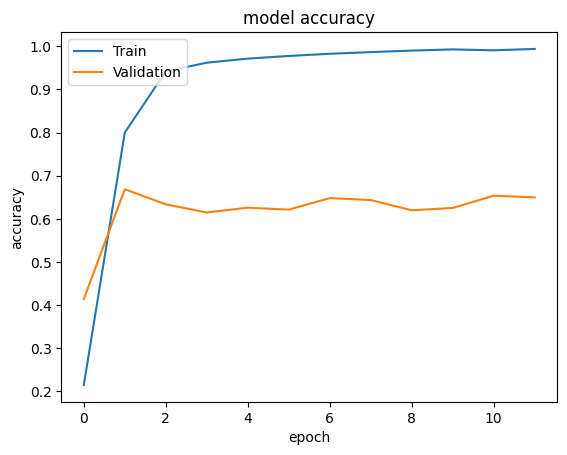

In [ ]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()


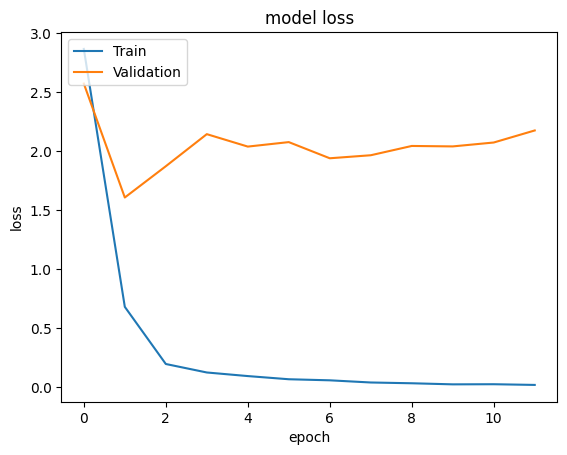

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

In [ ]:
from keras.wrappers.scikit_learn import KerasClassifier

estimator = KerasClassifier(build_fn=create_model)


<ipython-input-16-f610adb384d1>:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  estimator = KerasClassifier(build_fn=create_model)


In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=3)
grid_search.fit(train_hog_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size)


TypeError: ignored

In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best validation accuracy:", grid_search.best_score_)


###Hyperparameter turing 3

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'batch_size': [16, 32, 64],
    'img_size': [(32, 32), (64, 64), (128, 128)],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.001, 0.01, 0.1],
    'num_filters': [32, 64, 128],
    'num_dense_units': [256, 512, 1024]
}


In [ ]:
model = Sequential()
model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=img_size+(3,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(36, activation='softmax'))

In [ ]:
optimizer = Adam(lr=0.1)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history = model.fit(train_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size,
              validation_data=val_generator, validation_steps=val_generator.n//batch_size, verbose=0)

#return history.history['val_accuracy'][-1]


In [ ]:
grid_search = GridSearchCV(
    estimator=build_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

grid_result = grid_search.fit()

TypeError: ignored

###Sample1

In [ ]:
#sample1

model = Sequential()
model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36, activation='softmax'))

In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_hog_generator, epochs=15, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_hog_generator, validation_steps=val_generator.n//batch_size)


<ipython-input-4-bbb6df068774>:2: FutureWarning: `multichannel` is a deprecated argument name for `hog`. It will be removed in version 1.0. Please use `channel_axis` instead.
  fd, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, multichannel=True)


Epoch 1/15
136/136 [==============================] - 171s 1s/step - loss: 3.1954 - accuracy: 0.0960 - val_loss: 3.8670 - val_accuracy: 0.2329
Epoch 2/15
136/136 [==============================] - 167s 1s/step - loss: 1.7610 - accuracy: 0.4777 - val_loss: 4.6990 - val_accuracy: 0.3686
Epoch 3/15
136/136 [==============================] - 167s 1s/step - loss: 0.8815 - accuracy: 0.7398 - val_loss: 4.6563 - val_accuracy: 0.4347
Epoch 4/15
136/136 [==============================] - 169s 1s/step - loss: 0.4863 - accuracy: 0.8575 - val_loss: 4.6230 - val_accuracy: 0.4528
Epoch 5/15
136/136 [==============================] - 166s 1s/step - loss: 0.3093 - accuracy: 0.9072 - val_loss: 4.9693 - val_accuracy: 0.4884
Epoch 6/15
136/136 [==============================] - 167s 1s/step - loss: 0.2327 - accuracy: 0.9285 - val_loss: 5.1400 - val_accuracy: 0.4765
Epoch 7/15
136/136 [==============================] - 168s 1s/step - loss: 0.1761 - accuracy: 0.9440 - val_loss: 5.9148 - val_accuracy: 0.4596

In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_generator, epochs=15, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_generator, validation_steps=val_generator.n//batch_size)


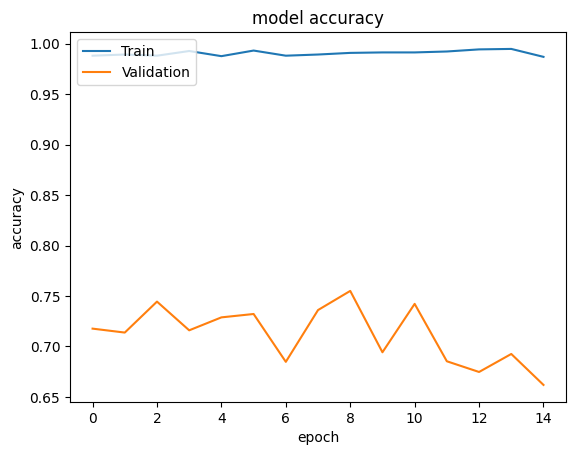

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

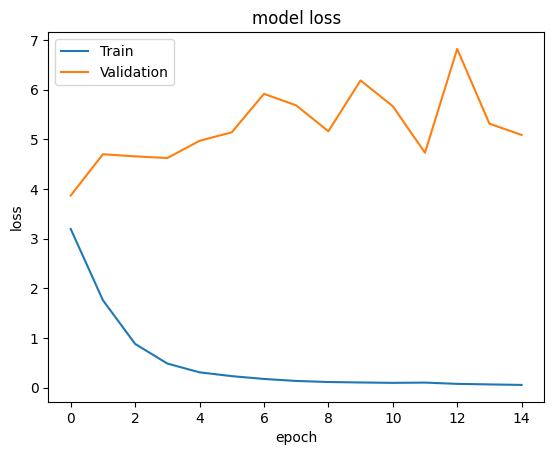

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

###Sample2

In [ ]:
#sample1

model = Sequential()
#model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
#model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(218, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(36, activation='softmax'))


# # define the CNN model architecture
# model = Sequential()
# model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(64, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Flatten())
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(36, activation='softmax'))

In [ ]:

# compile the model with appropriate optimizer, loss function, and metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:

# define callbacks to prevent overfitting
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min', min_lr=0.0001)


In [ ]:

# fit the model with the training dataset and validate it with the testing dataset
history = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[early_stop, reduce_lr])

Epoch 1/15
137/137 [==============================] - 1637s 12s/step - loss: 2.8680 - accuracy: 0.2149 - val_loss: 2.5743 - val_accuracy: 0.4142 - lr: 0.0010
Epoch 2/15
137/137 [==============================] - 134s 975ms/step - loss: 0.6824 - accuracy: 0.8000 - val_loss: 1.6091 - val_accuracy: 0.6685 - lr: 0.0010
Epoch 3/15
137/137 [==============================] - 140s 1s/step - loss: 0.1981 - accuracy: 0.9417 - val_loss: 1.8739 - val_accuracy: 0.6335 - lr: 0.0010
Epoch 4/15
137/137 [==============================] - 139s 1s/step - loss: 0.1262 - accuracy: 0.9619 - val_loss: 2.1458 - val_accuracy: 0.6147 - lr: 0.0010
Epoch 5/15
137/137 [==============================] - 134s 971ms/step - loss: 0.0958 - accuracy: 0.9713 - val_loss: 2.0404 - val_accuracy: 0.6258 - lr: 0.0010
Epoch 6/15
137/137 [==============================] - 140s 1s/step - loss: 0.0689 - accuracy: 0.9775 - val_loss: 2.0784 - val_accuracy: 0.6213 - lr: 0.0010
Epoch 7/15
137/137 [==============================] - ET

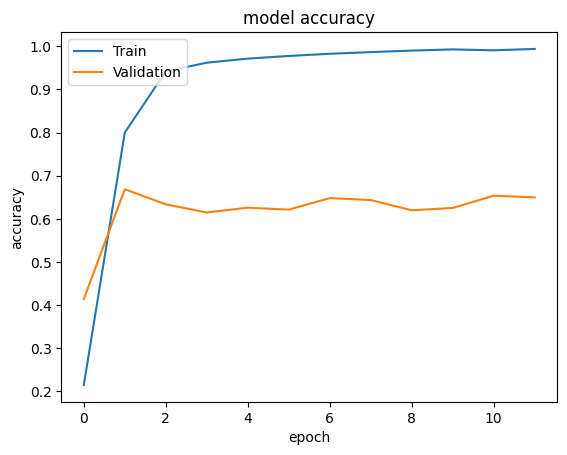

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

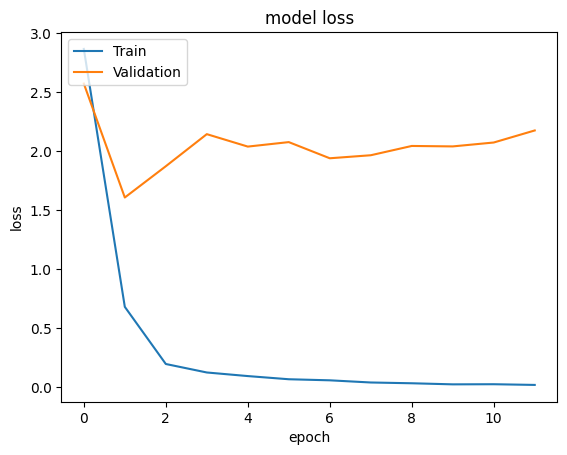

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

###Sample2 copy

In [ ]:
#sample1

model = Sequential()
#model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
#model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(218, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(36, activation='softmax'))


In [ ]:

# compile the model with appropriate optimizer, loss function, and metrics
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:

# define callbacks to prevent overfitting
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=15, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min', min_lr=0.0001)


In [ ]:

# fit the model with the training dataset and validate it with the testing dataset
history = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=[early_stop, reduce_lr])

Epoch 1/15
137/137 [==============================] - 154s 1s/step - loss: 2.4897 - accuracy: 0.3160 - val_loss: 2.0432 - val_accuracy: 0.5875 - lr: 0.0010
Epoch 2/15
137/137 [==============================] - 147s 1s/step - loss: 0.3085 - accuracy: 0.9162 - val_loss: 2.1344 - val_accuracy: 0.6074 - lr: 0.0010
Epoch 3/15
137/137 [==============================] - 147s 1s/step - loss: 0.1288 - accuracy: 0.9621 - val_loss: 2.0726 - val_accuracy: 0.5586 - lr: 0.0010
Epoch 4/15
137/137 [==============================] - 143s 1s/step - loss: 0.0859 - accuracy: 0.9741 - val_loss: 1.9669 - val_accuracy: 0.6519 - lr: 0.0010
Epoch 5/15
137/137 [==============================] - 145s 1s/step - loss: 0.0560 - accuracy: 0.9816 - val_loss: 1.9048 - val_accuracy: 0.6830 - lr: 0.0010
Epoch 6/15
137/137 [==============================] - 144s 1s/step - loss: 0.0391 - accuracy: 0.9878 - val_loss: 2.3059 - val_accuracy: 0.6385 - lr: 0.0010
Epoch 7/15
137/137 [==============================] - 147s 1s/st

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

###Sample22

In [ ]:

# define the CNN model architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36, activation='softmax'))


In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_hog_generator, epochs=5, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_hog_generator, validation_steps=val_generator.n//batch_size)


<ipython-input-4-bbb6df068774>:2: FutureWarning: `multichannel` is a deprecated argument name for `hog`. It will be removed in version 1.0. Please use `channel_axis` instead.
  fd, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, multichannel=True)


Epoch 1/5
136/136 [==============================] - 155s 1s/step - loss: 2.5104 - accuracy: 0.2762 - val_loss: 4.6313 - val_accuracy: 0.3186
Epoch 2/5
136/136 [==============================] - 163s 1s/step - loss: 0.6747 - accuracy: 0.8029 - val_loss: 4.8340 - val_accuracy: 0.4230
Epoch 3/5
136/136 [==============================] - 165s 1s/step - loss: 0.2286 - accuracy: 0.9308 - val_loss: 4.8515 - val_accuracy: 0.4710
Epoch 4/5
136/136 [==============================] - 163s 1s/step - loss: 0.1520 - accuracy: 0.9533 - val_loss: 6.2381 - val_accuracy: 0.4325
Epoch 5/5
136/136 [==============================] - ETA: 0s - loss: 0.0954 - accuracy: 0.9702

In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_generator, epochs=15, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_generator, validation_steps=val_generator.n//batch_size)


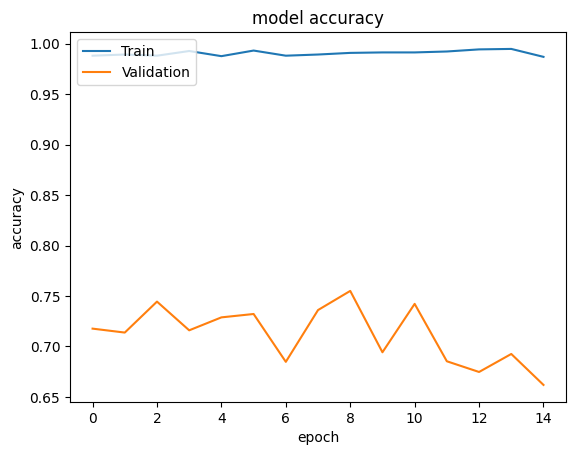

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation.png")
plt.show()

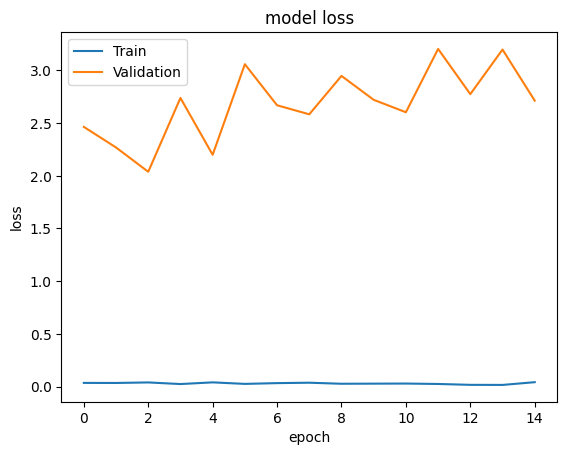

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig("resenet50_with_augmentation_loss.png")
plt.show()

###Sample 3

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:

# Set up data augmentation for training dataset
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)


In [ ]:
# Set up rescaling for validation dataset
val_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Set up the training dataset
train_set = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/datasplit/Train',
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary')


Found 4355 images belonging to 36 classes.


In [ ]:

# Set up the validation dataset
val_set = val_datagen.flow_from_directory(
        '/content/drive/MyDrive/datasplit/Test',
        target_size=(64, 64),
        batch_size=32,
        class_mode='binary')


Found 1801 images belonging to 36 classes.


In [ ]:
model = Sequential()
model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36, activation='softmax'))

In [ ]:

# # Define the CNN architecture
# cnn = Sequential()
# cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
# cnn.add(MaxPooling2D((2, 2)))
# cnn.add(Conv2D(64, (3, 3), activation='relu'))
# cnn.add(MaxPooling2D((2, 2)))
# cnn.add(Flatten())
# cnn.add(Dense(64, activation='relu'))
# cnn.add(Dropout(0.5)) # Add dropout layer to reduce overfitting
# cnn.add(Dense(1, activation='sigmoid'))


In [ ]:

# Compile the CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:

# Set up early stopping callback to stop training if validation loss does not improve
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:

# Train the CNN
model.fit(
        train_set,
        epochs=20,
        validation_data=val_set,
        callbacks=[early_stopping])


Epoch 1/20


ValueError: ignored

###Original

In [ ]:
model = Sequential()
model.add(Reshape((42, 42, 1), input_shape=(1764,)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36, activation='softmax'))

In [ ]:

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(train_hog_generator, epochs=10, steps_per_epoch=train_generator.n//batch_size,
          validation_data=val_hog_generator, validation_steps=val_generator.n//batch_size)


In [ ]:

val_loss, val_acc = model.evaluate(val_hog_generator, steps=val_generator.n//batch_size)
print('Validation Accuracy: {:.2f}%'.format(val_acc*100))

In [ ]:

test_dir = '/content/drive/MyDrive/datasplit/Test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
test_hog_generator = get_data_generator(test_generator)

test_loss, test_acc = model.evaluate(test_hog_generator, steps=test_generator.n//batch_size)
print('Test Accuracy: {:.2f}%'.format(test_acc*100))